In [12]:
print(df.duplicated().sum())

0


In [13]:
#On Time Delivery rate (0=On Time, 1= Late)
df["Late_delivery_risk"].value_counts()

Late_delivery_risk
1    98972
0    81536
Name: count, dtype: int64

In [14]:
#Average Transit Time
df["Days for shipping (real)"].mean()

np.float64(3.497673233319299)

In [15]:
#Cost per Shipment / Profit
df.groupby("Shipping Mode")["Benefit per order"].mean()

Shipping Mode
First Class       23.121689
Same Day          20.850203
Second Class      21.306438
Standard Class    21.993403
Name: Benefit per order, dtype: float64

In [16]:
import matplotlib.pyplot as plt 
import seaborn as sns

In [17]:
print(df["Product Price"].describe())

count    180508.000000
mean        141.222139
std         139.726960
min           9.990000
25%          50.000000
50%          59.990002
75%         199.990005
max        1999.989990
Name: Product Price, dtype: float64


In [18]:
Q1=df["Product Price"].quantile(0.25)
Q3=df["Product Price"].quantile(0.75)
IQR=Q3-Q1
df=df[-((df["Product Price"]<(Q1-1.5*IQR)) | (df["Product Price"]>(Q3+1.5*IQR)))]
print("Rows after removing outliners:",df.shape[0])

Rows after removing outliners: 178463


In [19]:
df.to_csv("cleaned_logistics.csv",index=False)
print("Clean file saved")

Clean file saved


In [20]:
print(df["Product Price"].describe())

count    178463.000000
mean        134.642912
std         117.313978
min           9.990000
25%          50.000000
50%          59.990002
75%         199.990005
max         399.989990
Name: Product Price, dtype: float64


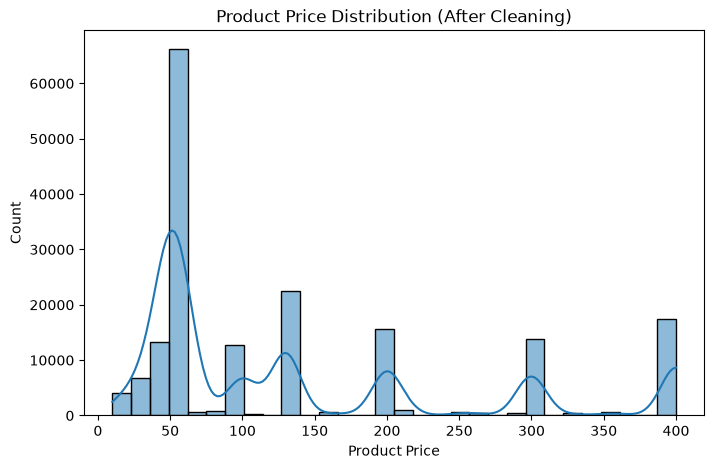

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
#This is your cleaned file
df=pd.read_csv("cleaned_logistics.csv")
plt.figure(figsize=(8,5))
sns.histplot(df["Product Price"], bins=30, kde=True)
plt.title("Product Price Distribution (After Cleaning)")
plt.xlabel("Product Price")
plt.ylabel("Count")
plt.show()

C:\Users\yashsharma\AppData\Local\Temp\ipykernel_3056\3117011323.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Shipping Mode", data=df, palette="Set2")


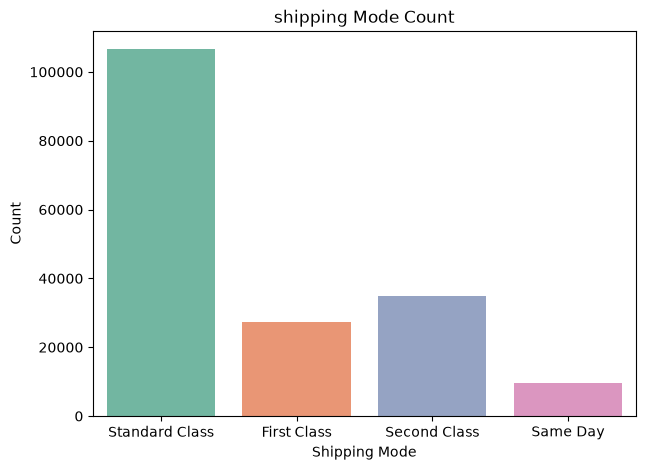

In [22]:
plt.figure(figsize=(7,5))
sns.countplot(x="Shipping Mode", data=df, palette="Set2")
plt.title("shipping Mode Count")
plt.xlabel("Shipping Mode")
plt.ylabel("Count")
plt.show()

In [23]:
df["Shipping Mode"].value_counts()

Shipping Mode
Standard Class    106538
Second Class       34830
First Class        27439
Same Day            9656
Name: count, dtype: int64

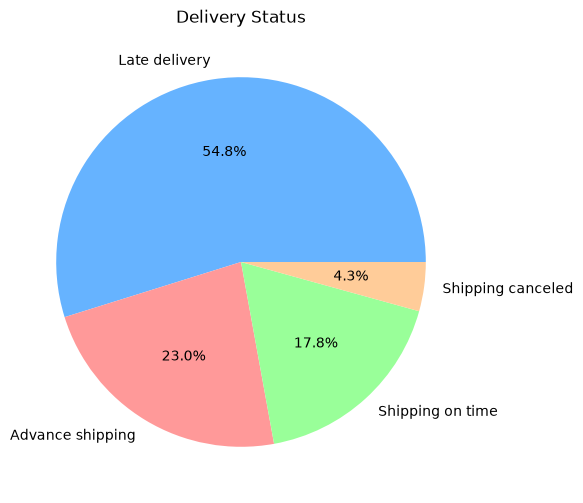

In [24]:
plt.figure(figsize=(6,6))
df["Delivery Status"].value_counts().plot.pie(autopct="%1.1f%%",colors=["#66b3ff","#ff9999","#99ff99","#ffcc99"])
plt.title("Delivery Status")
plt.ylabel("")
plt.show()

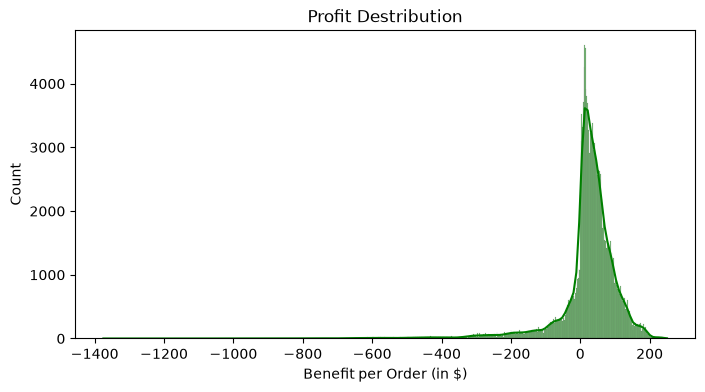

In [25]:
plt.figure(figsize=(8,4))
sns.histplot(df["Benefit per order"],kde=True,color="green")
plt.title("Profit Destribution")
plt.xlabel("Benefit per Order (in $)")
plt.show()

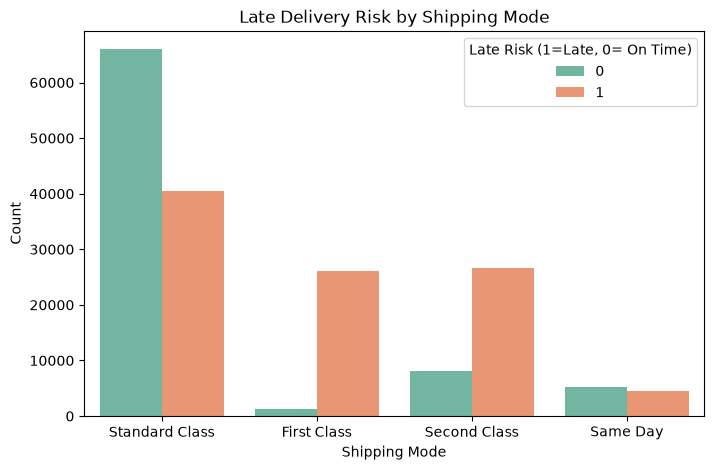

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(x="Shipping Mode", hue="Late_delivery_risk", data=df, palette="Set2")
plt.title("Late Delivery Risk by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Count")
plt.legend(title="Late Risk (1=Late, 0= On Time)")
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Late_delivery_risk", y="Days for shipping (real)", data= df, palette="pastel")
plt.title("Relation Between Real Shipping Days and Late Delivery Risk")
plt.xlabel("Late Delivery Risk (0 = No, 1 = Yes)")
plt.ylabel("Days for Shipping (real)")
plt.show()

C:\Users\yashsharma\AppData\Local\Temp\ipykernel_3056\3937313013.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Late_delivery_risk", y="Days for shipping (real)", data= df, palette="pastel")
